In [51]:
from reservoirpy.datasets import mackey_glass, lorenz
from reservoirpy.nodes import Reservoir, Ridge, Input
from reservoirpy.observables import rmse, rsquare
import matplotlib.pyplot as plt
from pyqpanda import *
import numpy as np
import matplotlib
matplotlib.rc("font",family='Kai')
plt.rcParams['axes.unicode_minus'] =False
%matplotlib widget

from all import *

In [1]:
import numpy as np


def generate_input_sequence(length):
    # 生成在[0, 1]上均匀分布的随机输入序列
    s_k = np.random.uniform(0, 1, length)
    return s_k


# 假设需要生成长度为100的输入序列
sequence_length = 100
input_sequence = generate_input_sequence(sequence_length)
print(input_sequence)

[0.58626139 0.97899083 0.02021206 0.93511329 0.82926337 0.73409306
 0.22616458 0.83135863 0.83783573 0.09809378 0.00364113 0.04275054
 0.62703088 0.48619245 0.2372426  0.09045659 0.262026   0.51894988
 0.06999884 0.8522661  0.12346748 0.03258488 0.70074596 0.49992086
 0.97204274 0.87537653 0.09789508 0.6126649  0.93350697 0.28072036
 0.58233499 0.77004824 0.03739482 0.85468609 0.90087019 0.56379739
 0.59715016 0.12528029 0.88666821 0.609444   0.97852395 0.18535585
 0.64030763 0.82557765 0.52422277 0.60078682 0.77628787 0.93198583
 0.47455313 0.41163968 0.45144318 0.99093755 0.41790365 0.07450192
 0.25204825 0.62696378 0.50077126 0.85144978 0.41694651 0.55952864
 0.39499365 0.70844338 0.37774061 0.69445723 0.98721324 0.55072013
 0.13760284 0.51232204 0.39923658 0.76263778 0.55070175 0.18491794
 0.81692293 0.2198451  0.32933142 0.63888881 0.14330968 0.62125404
 0.64322942 0.25037465 0.09704287 0.48389926 0.96198312 0.66385973
 0.54152678 0.74937013 0.45349445 0.12216907 0.75174953 0.6381

In [52]:
###Mackey-Glass
mg_series = mackey_glass(n_timesteps=4500,
                         tau=17, 
                         a=0.2, 
                         b=0.1, 
                         n=10, 
                         x0=1.2, 
                         h=1.0, 
                         seed=None)
mg_norm = (mg_series - np.min(mg_series)) / (np.max(mg_series) - np.min(mg_series))
print(mg_norm)

[[0.86037123]
 [0.79115074]
 [0.70729904]
 ...
 [0.79768718]
 [0.75082492]
 [0.69828637]]


In [53]:

def create_quantum_circuit(n_qubits, a_in, a_fb, s_k, params):
    """创建量子线路并对每个量子比特分别测量期望值"""
    def R_ij (q, params):
        prog = QProg()
        prog << RX(qubits[q], params)
        prog << RX(qubits[q+1], params) 
        prog << CNOT(qubits[q], qubits[q+1])
        prog << RZ(qubits[q+1], params)
        prog << CNOT(qubits[q], qubits[q+1])
        return prog
    # 初始化量子虚拟机
    qvm = init_quantum_machine(QMachineType.CPU)
    qubits = qvm.qAlloc_many(n_qubits)
    
    # 构建量子程序
    prog = QProg()
    prog << R_ij(0, a_in*s_k)
    prog << R_ij(2, a_fb * params[0])
    prog << R_ij(4, a_fb * params[1])
    prog << R_ij(6, a_fb * params[2])
    prog << R_ij(3, a_fb * params[3])
    prog << R_ij(5, a_fb * params[4])
    prog << R_ij(2, a_fb * params[5])
    prog << R_ij(4, a_fb * params[6])
    prog << R_ij(6, a_fb * params[7]) 

    z_k = []
    for i in range(n_qubits):
        # 构建仅作用于第 i 个量子比特的 Pauli 算符
        pauli_dict = {f"Z{i}": 1}
        p = PauliOperator(pauli_dict)
        Hmt = p.to_hamiltonian(False)
        expec = qvm.get_expectation(prog, Hmt, qubits)
        z_k.append(expec)
    z_k.append(1)
    destroy_quantum_machine(qvm)
    return z_k

In [54]:
all_probabilities = []
z_j = np.random.uniform(0, 1, 8).tolist()
z_j.append(1)
all_probabilities.append(z_j)
print(all_probabilities)

[[0.44856009842663425, 0.36354650775175645, 0.8133606532337769, 0.23146047149055837, 0.09677478978258669, 0.3084347910053987, 0.20042384857445106, 0.7491152851945794, 1]]


In [55]:
for i in range(len(mg_norm)):
    z_j = create_quantum_circuit(n_qubits=8, a_in=0.01, a_fb=6,s_k=mg_norm[i], params=z_j)
    all_probabilities.append(z_j)

/var/folders/vm/_5v9zp651sdfyy_2rjt_7w_w0000gn/T/ipykernel_11524/2258320329.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prog << RX(qubits[q], params)
/var/folders/vm/_5v9zp651sdfyy_2rjt_7w_w0000gn/T/ipykernel_11524/2258320329.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prog << RX(qubits[q+1], params)
/var/folders/vm/_5v9zp651sdfyy_2rjt_7w_w0000gn/T/ipykernel_11524/2258320329.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prog << RZ(qubits[q+1],

In [56]:

ridge, washout, nstop_train = train_ridge_model(washout=500, 
                                               nstop_train=2500, 
                                               alpha=0,
                                               loading_dataX=all_probabilities, 
                                               loading_datay=mg_norm)
                            
predictions = predict_next_state(method=ridge, 
                                 loading_dataX=all_probabilities, 
                                 loading_datay=mg_norm)

print(predictions)    

[1.08211876e+04 8.93675527e-01 7.86447262e-01 ... 8.44296822e-01
 8.02354402e-01 7.32161412e-01]


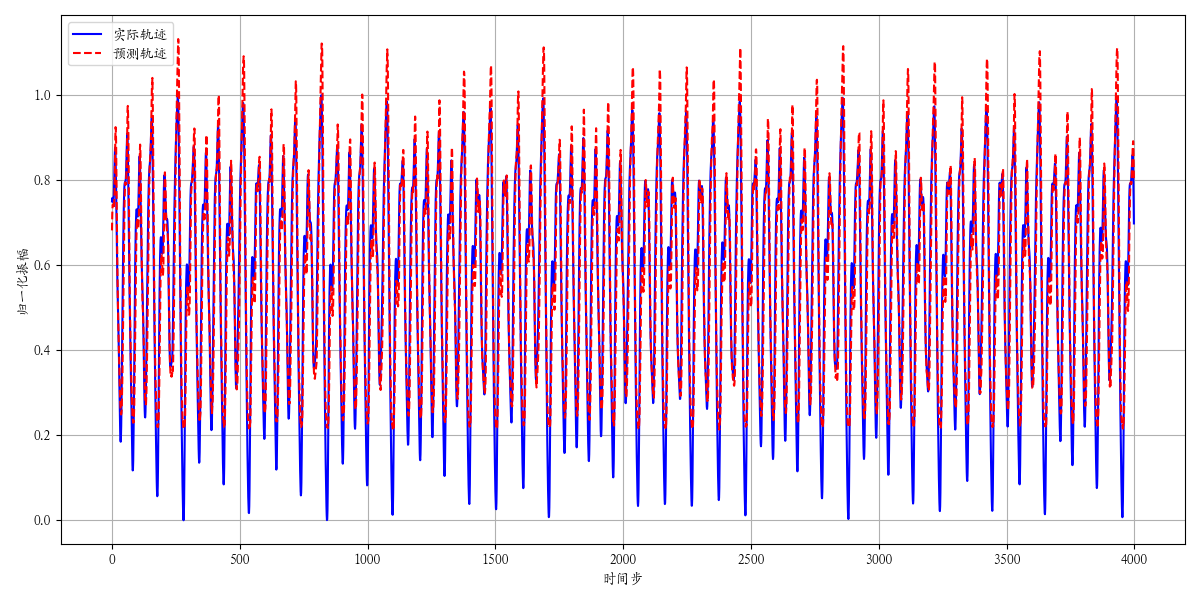

In [57]:
# 创建完整轨迹对比图
plt.figure(figsize=(12, 6))
plt.plot(mg_norm[501:], 'b-', label='实际轨迹')
plt.plot(predictions[500:-1], 'r--', label='预测轨迹')
plt.xlabel('时间步')
plt.ylabel('归一化振幅')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()